# Freddie Mac — 11F controlled experiment: remove Original_UPB only

This notebook is a controlled 11-feature ablation of the corrected 12F feature set. It retains `DTI_Missing` as a categorical predictor and removes **only** `Original_UPB` after the same internal Train split and 12F VIF reduction. `Original_UPB` remains in the original candidate pool solely to reproduce the 12F VIF decision; it is absent from every final modeling matrix and fit.

Logistic Regression, CatBoost and LightGBM use the fixed parameters selected in the 12F experiment. **No new hyperparameter search is performed.** The internal stratified 80/20 split (`random_state=3217`), five-fold overfit diagnosis, decision threshold 0.015, original `my_ml.fit_pipeline()` preprocessing and CatBoost fit-time categorical declaration are retained from the supplied controlled template.

The `Original_DTI` values originally missing were imputed upstream to 35. `DTI_Missing` preserves their original missing status. This notebook does not re-impute DTI or change the upstream parquet. Use Restart & Run All, with the project `helpers` module and ML-ready parquet available.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from helpers import *

PROJECT_NAME = "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams"
RANDOM_STATE = 3217
TEST_SIZE = 0.20
THRESHOLD = 0.015
VIF_THRESHOLD = 10.0
TARGET = "Target_24M"
GAP_THRESHOLD = 0.20

print("PROJECT_NAME =", PROJECT_NAME)
print("RANDOM_STATE =", RANDOM_STATE)
print("THRESHOLD    =", THRESHOLD)


PROJECT_NAME = SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams
RANDOM_STATE = 3217
THRESHOLD    = 0.015


In [2]:
DATA_CANDIDATES = [
    Path(r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("../data/output/model_ready/SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("data/output/model_ready/SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("SFLLD_regular_PIT_train_ML_ready.parquet"),
]
DATA_PATH = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find SFLLD_regular_PIT_train_ML_ready.parquet. Searched:\n"
        + "\n".join(str(p.resolve()) for p in DATA_CANDIDATES)
    )

df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())


Loaded: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet
Shape : 160,003 rows x 56 columns


,Loan_ID,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,...,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Final,BLS_Employment_Growth_12M_Final,BLS_Unemployment_Rate_Change_12M_Final,Regular_State_Macro_Cluster_A,Regular_State_Macro_Cluster_B,Regular_MSA_Macro_Cluster_A,Regular_MSA_Macro_Cluster_A_Fallback,Regular_MSA_Macro_Cluster_B,Regular_MSA_Macro_Cluster_B_Fallback
0,F10Q20367887,752.0,2017-02-01,1,2040-06-01,235,0.0,0,1,65.0,...,0.041253,1.360977,0.031252,-0.1,1,2,0,0,0,0
1,F12Q40587216,791.0,2014-02-01,1,2044-01-01,452,0.0,0,1,38.0,...,0.122742,2.091864,0.018115,-0.9,1,1,0,1,1,1
2,F12Q40587224,708.0,2014-01-01,1,2043-12-01,435,0.0,0,1,64.0,...,0.031745,1.902108,0.002431,-1.1,2,1,0,0,0,0
3,F12Q40590818,682.0,2014-02-01,1,2042-12-01,99,0.0,0,1,62.0,...,0.066397,1.722767,0.032153,-0.8,1,1,1,0,1,0
4,F12Q40593033,787.0,2015-03-01,1,2028-01-01,282,0.0,0,1,55.0,...,0.038772,1.547563,0.013646,-0.7,2,2,1,0,0,0


In [ ]:
# Same categorical definition and set_type() behavior as the two original notebooks.
CATEGORICAL_COLS = [
    "First_Time_Homebuyer","MSA","Number_of_Units","Occupancy_Status","Channel",
    "Property_State","Property_Type","Postal_Code","Loan_Purpose","Seller_Name",
    "Super_Conforming_Flag","HARP_Indicator","DTI_Missing","FICO_Risk_Band",
    "DTI_Risk_Band","LTV_Risk_Component","CLTV_Risk_Component","High_Leverage",
    "HARP_High_Leverage","Spatial_Cluster","Spatial_Cluster_Region",
    "Regular_State_Macro_Cluster_A","Regular_State_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A","Regular_MSA_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A_Fallback","Regular_MSA_Macro_Cluster_B_Fallback",
]

available_categorical = [c for c in CATEGORICAL_COLS if c in df.columns]
df = my_qtcheck.set_type(df, as_category=available_categorical)

failed = [
    c for c in available_categorical
    if not (
        isinstance(df[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(df[c].dtype)
    )
]
if failed:
    raise TypeError("Categorical conversion FAILED: " + str(failed))

print(f"✓ TYPE CONVERSION VERIFIED: {len(available_categorical)} categorical variables")

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  category      
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  category      
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  category      
 8   Occupancy_Status                        160003 non-null  category      
 9   Original_CLTV                           160003 n

In [ ]:
# Same original 14-variable M8 candidate pool.
M8 = [
    "FICO_Score", "Original_DTI", "Original_CLTV",
    "Original_Interest_Rate", "Number_of_Borrowers", "Original_UPB",
    "DTI_LTV_Interaction", "DTI_Rate_Interaction",
    "DTI_Missing", "HARP_High_Leverage", "Spatial_Cluster_Region",
    "Housing_HPI_Growth_12M", "BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]

missing = [c for c in M8 + [TARGET] if c not in df.columns]
if missing:
    raise KeyError(f"Required columns missing: {missing}")

M8_CATEGORICAL = [c for c in M8 if c in CATEGORICAL_COLS]
M8_CONTINUOUS = [c for c in M8 if c not in CATEGORICAL_COLS]

rows = []
for c in M8:
    is_cat = (
        isinstance(df[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(df[c].dtype)
    )
    expected = "Categorical" if c in M8_CATEGORICAL else "Continuous"
    passed = is_cat if expected == "Categorical" else pd.api.types.is_numeric_dtype(df[c])
    rows.append([c, expected, str(df[c].dtype), df[c].nunique(dropna=True), is_cat, passed])

type_audit = pd.DataFrame(
    rows,
    columns=["Feature","Expected_Type","Actual_dtype","N_Unique","Detected_As_Categorical","PASS"]
)
display(type_audit)

bad = type_audit.loc[~type_audit.PASS, "Feature"].tolist()
if bad:
    raise TypeError(f"TYPE AUDIT FAILED — ML blocked: {bad}")

print("✓ TYPE AUDIT PASSED")

,Feature,Expected_Type,Actual_dtype,N_Unique,Detected_As_Categorical,PASS
0,FICO_Score,Continuous,float64,355,False,True
1,Original_DTI,Continuous,float64,50,False,True
2,Original_CLTV,Continuous,float64,226,False,True
3,Original_Interest_Rate,Continuous,float64,696,False,True
4,Number_of_Borrowers,Continuous,int64,2,False,True
5,Original_UPB,Continuous,int64,709,False,True
6,DTI_LTV_Interaction,Continuous,float64,1768,False,True
7,DTI_Rate_Interaction,Continuous,float64,2762,False,True
8,DTI_Missing,Categorical,category,2,True,True
9,HARP_High_Leverage,Categorical,category,2,True,True


✓ TYPE AUDIT PASSED


In [ ]:
# Rebuild the SAME split from the SAME 14-variable M8 pool.
X_all = df[M8].copy()
y_all = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

print(f"Full dataset   : {len(df):,}")
print(f"Internal train : {len(X_train):,}")
print(f"Internal test  : {len(X_test):,}")
print("Train/Test index overlap:", len(set(X_train.index) & set(X_test.index)))
print("\nTrain target rate:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest target rate:")
print(y_test.value_counts(normalize=True).sort_index())

Full dataset   : 160,003
Internal train : 128,002
Internal test  : 32,001
Train/Test index overlap: 0

Train target rate:
Target_24M
0    0.994258
1    0.005742
Name: proportion, dtype: float64

Test target rate:
Target_24M
0    0.99425
1    0.00575
Name: proportion, dtype: float64


In [ ]:
# Same hierarchy-preserving VIF reduction as the original corrected-M8 notebooks.
def vif_table(data, columns):
    x = data[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.isna().any().any():
        raise ValueError(
            f"VIF input has missing/non-finite values: {x.columns[x.isna().any()].tolist()}"
        )
    xc = add_constant(x, has_constant="add")
    return (
        pd.DataFrame([
            {"Feature": col, "VIF": variance_inflation_factor(xc.values, i)}
            for i, col in enumerate(x.columns, start=1)
        ])
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

INTERACTION_PRIORITY = ["DTI_Rate_Interaction", "DTI_LTV_Interaction"]
continuous_final = M8_CONTINUOUS.copy()
removed_for_vif = []

while True:
    vt = vif_table(X_train, continuous_final)
    if vt.VIF.max() <= VIF_THRESHOLD:
        break

    offenders = vt.loc[vt.VIF > VIF_THRESHOLD, "Feature"].tolist()
    drop_col = next(
        (c for c in INTERACTION_PRIORITY if c in offenders and c in continuous_final),
        None,
    )
    if drop_col is None:
        drop_col = vt.iloc[0].Feature

    continuous_final.remove(drop_col)
    removed_for_vif.append(drop_col)
    print("Removed for VIF:", drop_col)

    if len(continuous_final) < 2:
        raise RuntimeError("Too few continuous predictors remain.")

vif_final = vif_table(X_train, continuous_final)
display(vif_final)
print("Removed for VIF:", removed_for_vif)
assert (vif_final.VIF <= VIF_THRESHOLD).all()
print("✓ FINAL VIF CHECK PASSED")

Removed for VIF: DTI_Rate_Interaction
Removed for VIF: DTI_LTV_Interaction


,Feature,VIF
0,Original_Interest_Rate,1.226023
1,Original_CLTV,1.107899
2,Original_UPB,1.100411
3,FICO_Score,1.088102
4,BLS_Unemployment_Rate_Change_12M_Final,1.085848
5,Housing_HPI_Growth_12M,1.083098
6,Original_DTI,1.062070
7,Number_of_Borrowers,1.040497


Removed for VIF: ['DTI_Rate_Interaction', 'DTI_LTV_Interaction']
✓ FINAL VIF CHECK PASSED


In [ ]:
# 11F controlled ablation: corrected 12F M8 minus ONLY Original_UPB.
ABLATION_REMOVE = ["Original_UPB"]

M8_AFTER_VIF = [c for c in M8 if c not in removed_for_vif]
M8_FINAL = [c for c in M8_AFTER_VIF if c not in ABLATION_REMOVE]

FINAL_CATEGORICAL = [c for c in M8_FINAL if c in CATEGORICAL_COLS]
FINAL_CONTINUOUS = [c for c in M8_FINAL if c not in CATEGORICAL_COLS]

X_train_final = X_train[M8_FINAL].copy()
X_test_final = X_test[M8_FINAL].copy()

wrong_cats = [
    c for c in FINAL_CATEGORICAL
    if not (
        isinstance(X_train_final[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(X_train_final[c].dtype)
    )
]
wrong_nums = [
    c for c in FINAL_CONTINUOUS
    if not pd.api.types.is_numeric_dtype(X_train_final[c])
]

if wrong_cats or wrong_nums:
    raise TypeError(
        f"PRE-ML TYPE GATE FAILED: categorical={wrong_cats}, numeric={wrong_nums}"
    )

if len(M8_FINAL) != 11:
    raise RuntimeError(f"Expected exactly 11 final features, got {len(M8_FINAL)}: {M8_FINAL}")

EXPECTED_11F = [
    "FICO_Score","Original_DTI","Original_CLTV","Original_Interest_Rate",
    "Number_of_Borrowers","DTI_Missing","HARP_High_Leverage","Spatial_Cluster_Region",
    "Housing_HPI_Growth_12M","BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]
assert M8_FINAL == EXPECTED_11F, f"Unexpected 11F order/set: {M8_FINAL}"
assert "Original_UPB" not in X_train_final and "Original_UPB" not in X_test_final
assert "DTI_Missing" in FINAL_CATEGORICAL and "Original_DTI" in FINAL_CONTINUOUS
assert X_train_final.columns.tolist() == X_test_final.columns.tolist()
assert not X_train_final.isna().any().any() and not X_test_final.isna().any().any(), "Selected features contain NaN"

print("M8_FINAL =", M8_FINAL)
print("Categorical =", FINAL_CATEGORICAL)
print("Continuous  =", FINAL_CONTINUOUS)
print("✓ PRE-ML TYPE GATE PASSED — exactly the 11F feature set; Original_UPB excluded, DTI_Missing retained.")

M8_FINAL = ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'HARP_High_Leverage', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
Categorical = ['DTI_Missing', 'HARP_High_Leverage', 'Spatial_Cluster_Region', 'Regular_MSA_Macro_Cluster_A']
Continuous  = ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final']
✓ PRE-ML TYPE GATE PASSED — exactly the 11F feature set; Original_UPB excluded, DTI_Missing retained.


In [8]:
# Missing-DTI lineage QA — distinguish imputed 35 from observed 35.
assert "DTI_Missing" in df.columns and "Original_DTI" in df.columns
indicator = pd.to_numeric(df["DTI_Missing"].astype("string"), errors="raise").astype(int)
assert indicator.isin([0, 1]).all()
assert df.loc[indicator.eq(1), "Original_DTI"].eq(35).all(), (
    "Upstream imputed DTI is not uniformly 35; inspect the frozen treatment manifest."
)
print("Originally missing DTI in internal Train:", int(pd.to_numeric(X_train_final["DTI_Missing"].astype("string")).sum()))
print("Originally missing DTI in internal Test :", int(pd.to_numeric(X_test_final["DTI_Missing"].astype("string")).sum()))
print("Observed DTI=35 (full input):", int((indicator.eq(0) & df["Original_DTI"].eq(35)).sum()))
print("Imputed DTI=35 (full input) :", int(indicator.sum()))
print("PASS — 11F keeps the original missingness marker separately from imputed Original_DTI.")

Originally missing DTI in internal Train: 12840
Originally missing DTI in internal Test : 3161
Observed DTI=35 (full input): 5016
Imputed DTI=35 (full input) : 16001
PASS — 11F keeps the original missingness marker separately from imputed Original_DTI.


## Baseline — only the three requested models

These pipelines are built with the same `my_ml.fit_pipeline()` settings used inside the original `my_ml.cls_baseline()`:

- Logistic: `scale=True`, `drop_first=True`
- LightGBM: `scale=False`, `encode=True`
- CatBoost: `scale=False`, `encode=False`, with categorical column names supplied as `model__cat_features` **only at fit time**


In [ ]:
BASELINE_DIR = Path(PROJECT_NAME) / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

baseline_models = {}

# Logistic — mirrors my_ml.cls_baseline()
logistic_base = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
)
baseline_models["logistic"] = my_ml.fit_pipeline(
    model=logistic_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=True,
    drop_first=True,
    name="logistic",
    save_path=BASELINE_DIR / "logistic.pkl",
    verbose=False,
)

# LightGBM — mirrors my_ml.cls_baseline()
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
baseline_models["lgbm"] = my_ml.fit_pipeline(
    model=lgbm_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=False,
    encode=True,
    name="lgbm",
    save_path=BASELINE_DIR / "lgbm.pkl",
    verbose=False,
)

# CatBoost — mirrors my_ml.cls_baseline().
# IMPORTANT: no astype(str), no constructor cat_features.
catboost_base = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=0,
)
baseline_models["catboost"] = my_ml.fit_pipeline(
    model=catboost_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=False,
    encode=False,
    name="catboost",
    save_path=BASELINE_DIR / "catboost.pkl",
    verbose=False,
    model__cat_features=list(FINAL_CATEGORICAL),
)

print("✓ Three original-style baseline pipelines fitted and saved.")
print(list(baseline_models))

✓ Three original-style baseline pipelines fitted and saved.
['logistic', 'lgbm', 'catboost']


In [ ]:
def evaluate_model(estimator, X, y, threshold=THRESHOLD):
    prob = estimator.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob),
    }

baseline_rows = []
for name, estimator in baseline_models.items():
    row = {"Model": name, **evaluate_model(estimator, X_test_final, y_test)}
    baseline_rows.append(row)

baseline_scores = (
    pd.DataFrame(baseline_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
print("BASELINE — held-out test")
display(baseline_scores)

BASELINE — held-out test


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,catboost,0.926690,0.032439,0.407609,0.060096,0.823735,0.030826
1,logistic,0.925971,0.032120,0.407609,0.059547,0.836060,0.031493
2,lgbm,0.931346,0.027687,0.320652,0.050972,0.828289,0.029223


## Fixed 12F-selected parameters, fitted on 11F

No new grid search is performed. The **12F tuning-selected parameters** are applied to the same original-style 10F pipelines. This is the controlled 12F-vs-10F comparison.


In [ ]:
from sklearn.base import clone

FIXED_PARAMS = {
    "logistic": {
        "model__C": 0.01,
        "model__class_weight": None,
        "model__solver": "lbfgs",
    },
    "catboost": {
        "model__depth": 4,
        "model__iterations": 500,
        "model__learning_rate": 0.03,
    },
    "lgbm": {
        "model__learning_rate": 0.03,
        "model__n_estimators": 600,
        "model__num_leaves": 31,
    },
}

TUNED_DIR = Path(PROJECT_NAME) / "tuned"
TUNED_DIR.mkdir(parents=True, exist_ok=True)

fixed_tuned_models = {}

for name in ["logistic", "catboost", "lgbm"]:
    estimator = clone(baseline_models[name])
    estimator.set_params(**FIXED_PARAMS[name])

    print("\n" + "=" * 90)
    print("FIXED TUNED FIT:", name)
    print("Parameters:", FIXED_PARAMS[name])
    print("=" * 90)

    if name == "catboost":
        # Exactly the original my_ml behavior: fit-time categorical names.
        estimator.fit(
            X_train_final,
            y_train,
            model__cat_features=list(FINAL_CATEGORICAL),
        )
    else:
        estimator.fit(X_train_final, y_train)

    my_ml.save_model(estimator, TUNED_DIR / f"{name}_tuned.pkl")
    fixed_tuned_models[name] = estimator

print("\n✓ All three fixed-tuned models fitted and saved.")


FIXED TUNED FIT: logistic
Parameters: {'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'lbfgs'}

FIXED TUNED FIT: catboost
Parameters: {'model__depth': 4, 'model__iterations': 500, 'model__learning_rate': 0.03}

FIXED TUNED FIT: lgbm
Parameters: {'model__learning_rate': 0.03, 'model__n_estimators': 600, 'model__num_leaves': 31}

✓ All three fixed-tuned models fitted and saved.


In [ ]:
tuned_rows = []
for name, estimator in fixed_tuned_models.items():
    row = {"Model": name, **evaluate_model(estimator, X_test_final, y_test)}
    tuned_rows.append(row)

tuned_scores = (
    pd.DataFrame(tuned_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

print("FIXED TUNED — held-out test")
display(tuned_scores)

FIXED TUNED — held-out test


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,logistic,0.931565,0.035218,0.413043,0.064902,0.842055,0.032213
1,catboost,0.917346,0.031238,0.445652,0.058384,0.855255,0.048629
2,lgbm,0.933096,0.031594,0.358696,0.058073,0.829615,0.029237


In [ ]:
# Parameter audit — verify that the actual fitted inner models use the requested 12F parameters.
audit_rows = []

for name, estimator in fixed_tuned_models.items():
    params = estimator.get_params(deep=True)
    for key, expected in FIXED_PARAMS[name].items():
        actual = params.get(key)
        passed = (actual == expected)
        audit_rows.append([name, key, expected, actual, passed])

param_audit = pd.DataFrame(
    audit_rows,
    columns=["Model","Parameter","Expected","Actual","PASS"]
)
display(param_audit)

if not param_audit["PASS"].all():
    raise AssertionError("FIXED PARAMETER AUDIT FAILED")

print("✓ FIXED PARAMETER AUDIT PASSED")

,Model,Parameter,Expected,Actual,PASS
0,logistic,model__C,0.01,0.01,True
1,logistic,model__class_weight,None,None,True
2,logistic,model__solver,lbfgs,lbfgs,True
3,catboost,model__depth,4,4,True
4,catboost,model__iterations,500,500,True
5,catboost,model__learning_rate,0.03,0.03,True
6,lgbm,model__learning_rate,0.03,0.03,True
7,lgbm,model__n_estimators,600,600,True
8,lgbm,model__num_leaves,31,31,True


✓ FIXED PARAMETER AUDIT PASSED


## `my_diag.overfit()` — original pipeline behavior retained

For CatBoost, `fit_params={"model__cat_features": FINAL_CATEGORICAL}` is passed to `my_diag.overfit()`.  
This is essential because `my_diag.overfit()` internally performs CV cloning/refitting. The categorical information therefore remains a **fit-time argument**, matching the original `my_ml` workflow, rather than becoming a CatBoost constructor parameter.



OVERFIT DIAGNOSIS — FIXED TUNED: logistic


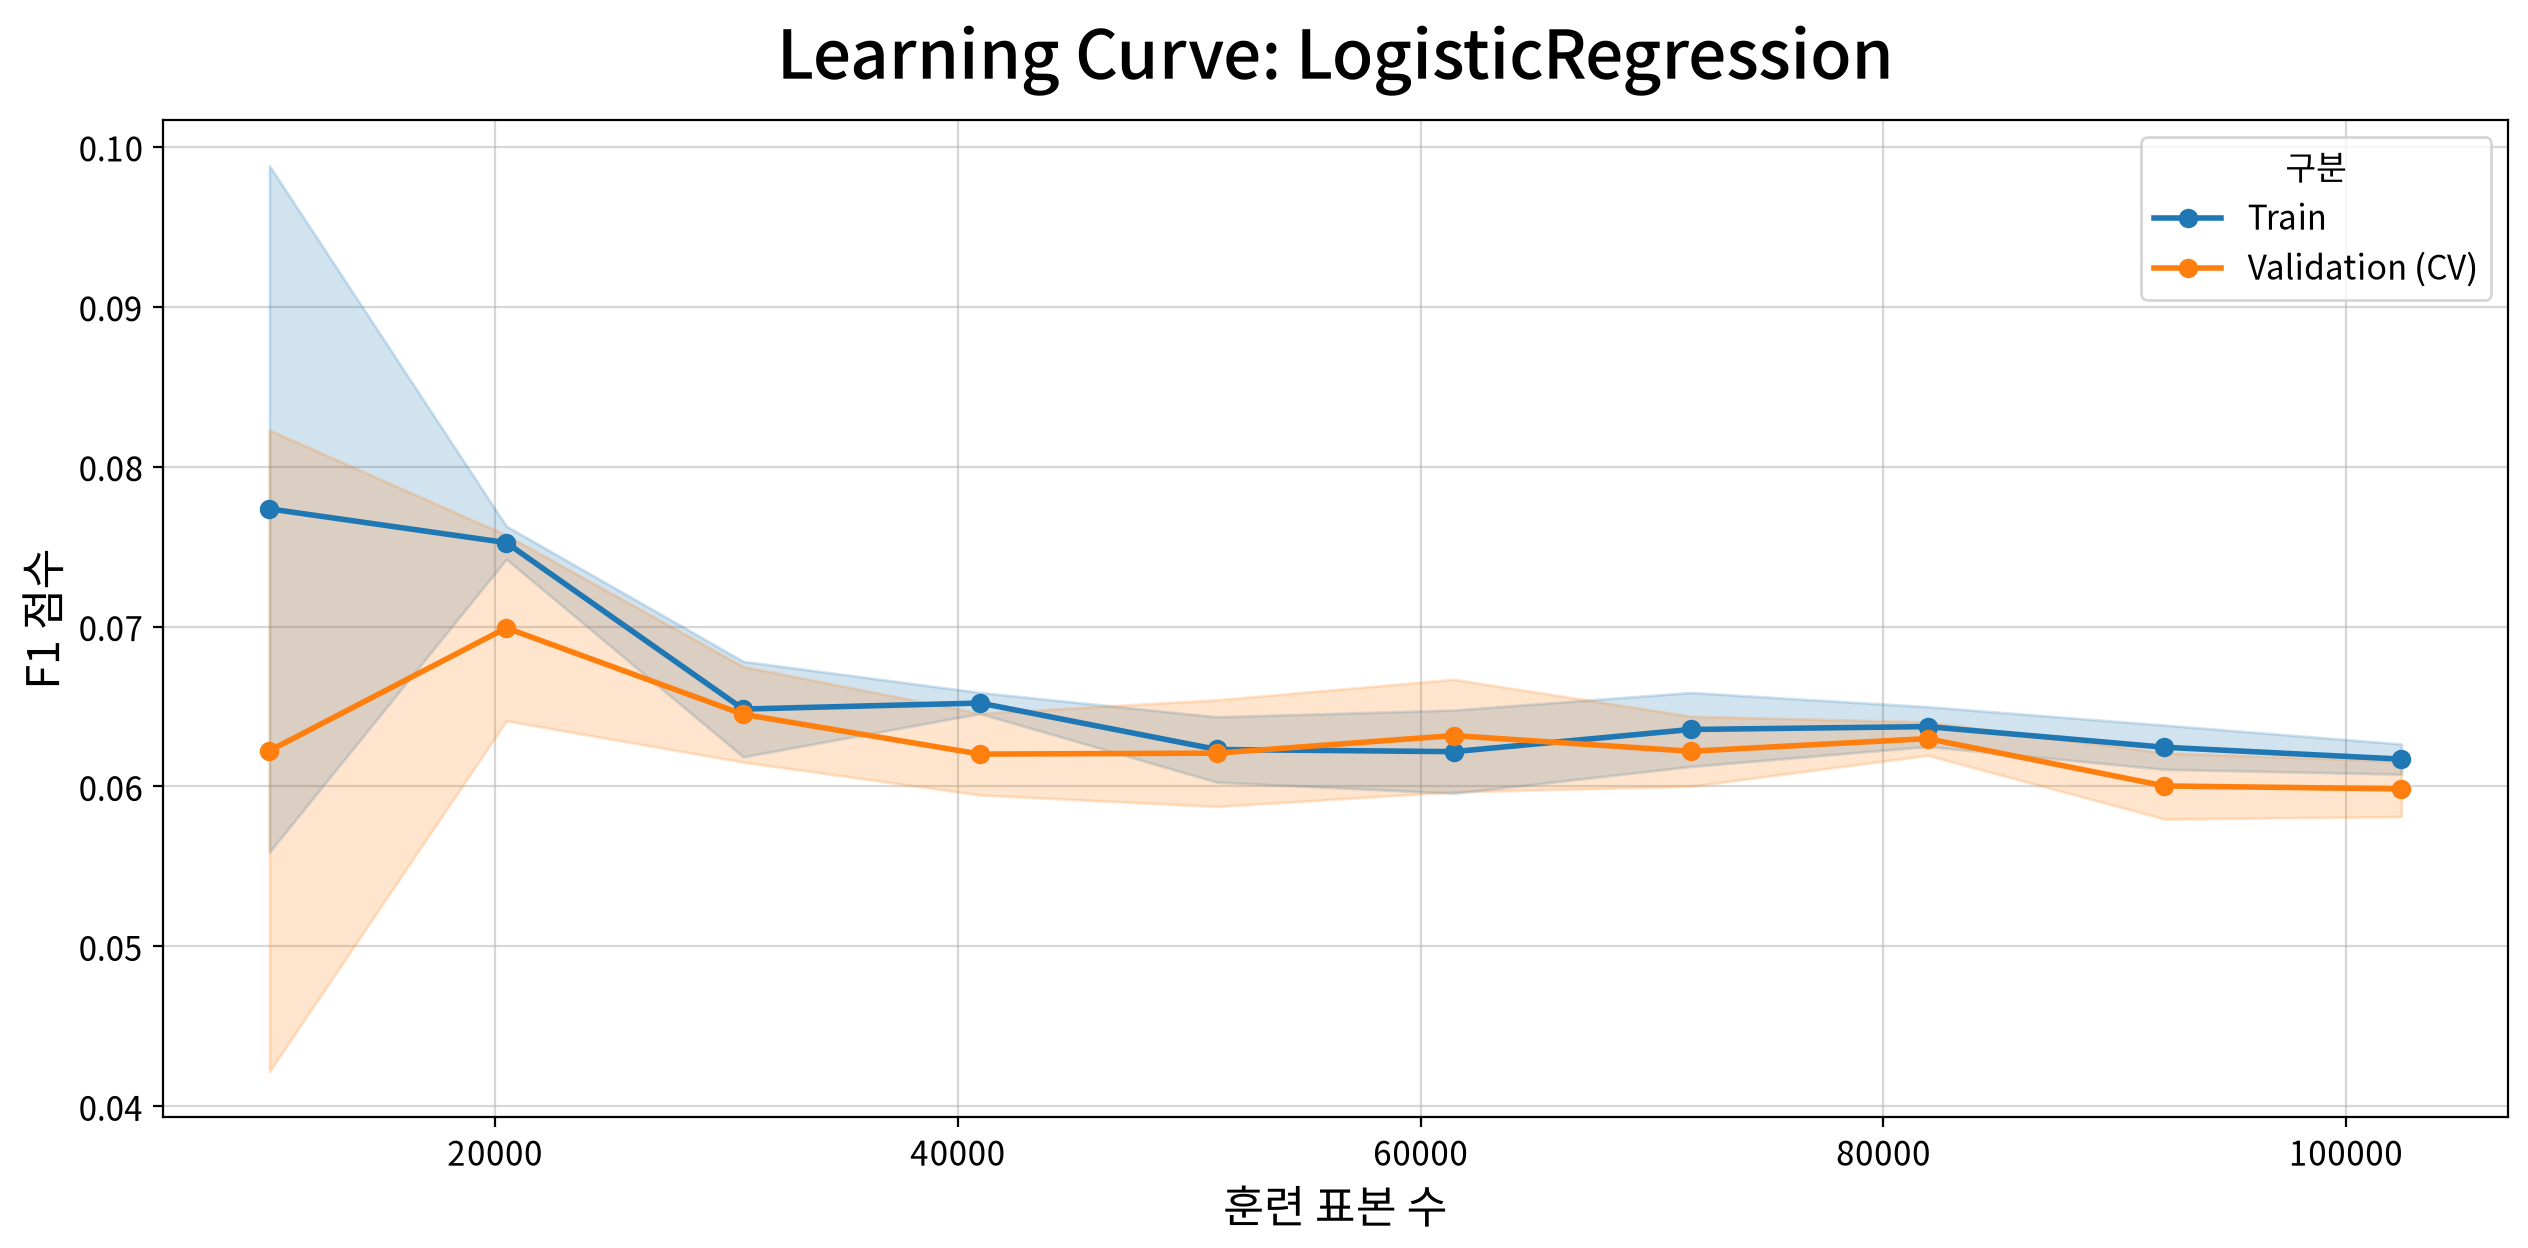

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.060774,0.059805,0.001570,0.064902,0.000969,0.10,일반화
PR_AUC,0.028863,0.029106,0.002208,0.032213,-0.000243,-0.02,일반화
ROC_AUC,0.821947,0.818332,0.005326,0.842055,0.003615,0.36,일반화
Recall,0.402721,0.380952,0.014904,0.413043,0.021769,2.18,일반화
Precision,0.032867,0.032452,0.000859,0.035218,0.000415,0.04,일반화
Accuracy,0.928525,0.931220,0.002033,0.931565,-0.002695,-0.27,일반화



◆ Fit Diagnosis: LogisticRegression  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.0608 CV=     0.0598 (±0.0016) Test=     0.0649 Gap=   0.0010 Gap%=   0.10% [일반화] [정상]
 - PR_AUC    Train=     0.0289 CV=     0.0291 (±0.0022) Test=     0.0322 Gap=  -0.0002 Gap%=  -0.02% [일반화] [정상]
 - ROC_AUC   Train=     0.8219 CV=     0.8183 (±0.0053) Test=     0.8421 Gap=   0.0036 Gap%=   0.36% [일반화] [정상]
 - Recall    Train=     0.4027 CV=     0.3810 (±0.0149) Test=     0.4130 Gap=   0.0218 Gap%=   2.18% [일반화] [정상]
 - Precision Train=     0.0329 CV=     0.0325 (±0.0009) Test=     0.0352 Gap=   0.0004 Gap%=   0.04% [일반화] [정상]
 - Accuracy  Train=     0.9285 CV=     0.9312 (±0.0020) Test=     0.9316 Gap=  -0.0027 Gap%=  -0.27% [일반화] [정상]

  ▶ 진단: ✔ 일반화 진단 (Good fit) - 설정한 gap 기준 내에서 격차가 작음
     · train ROC_AUC=0.8219 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8183


OVERFIT DIAGNOSIS — FIXED TUNED: c

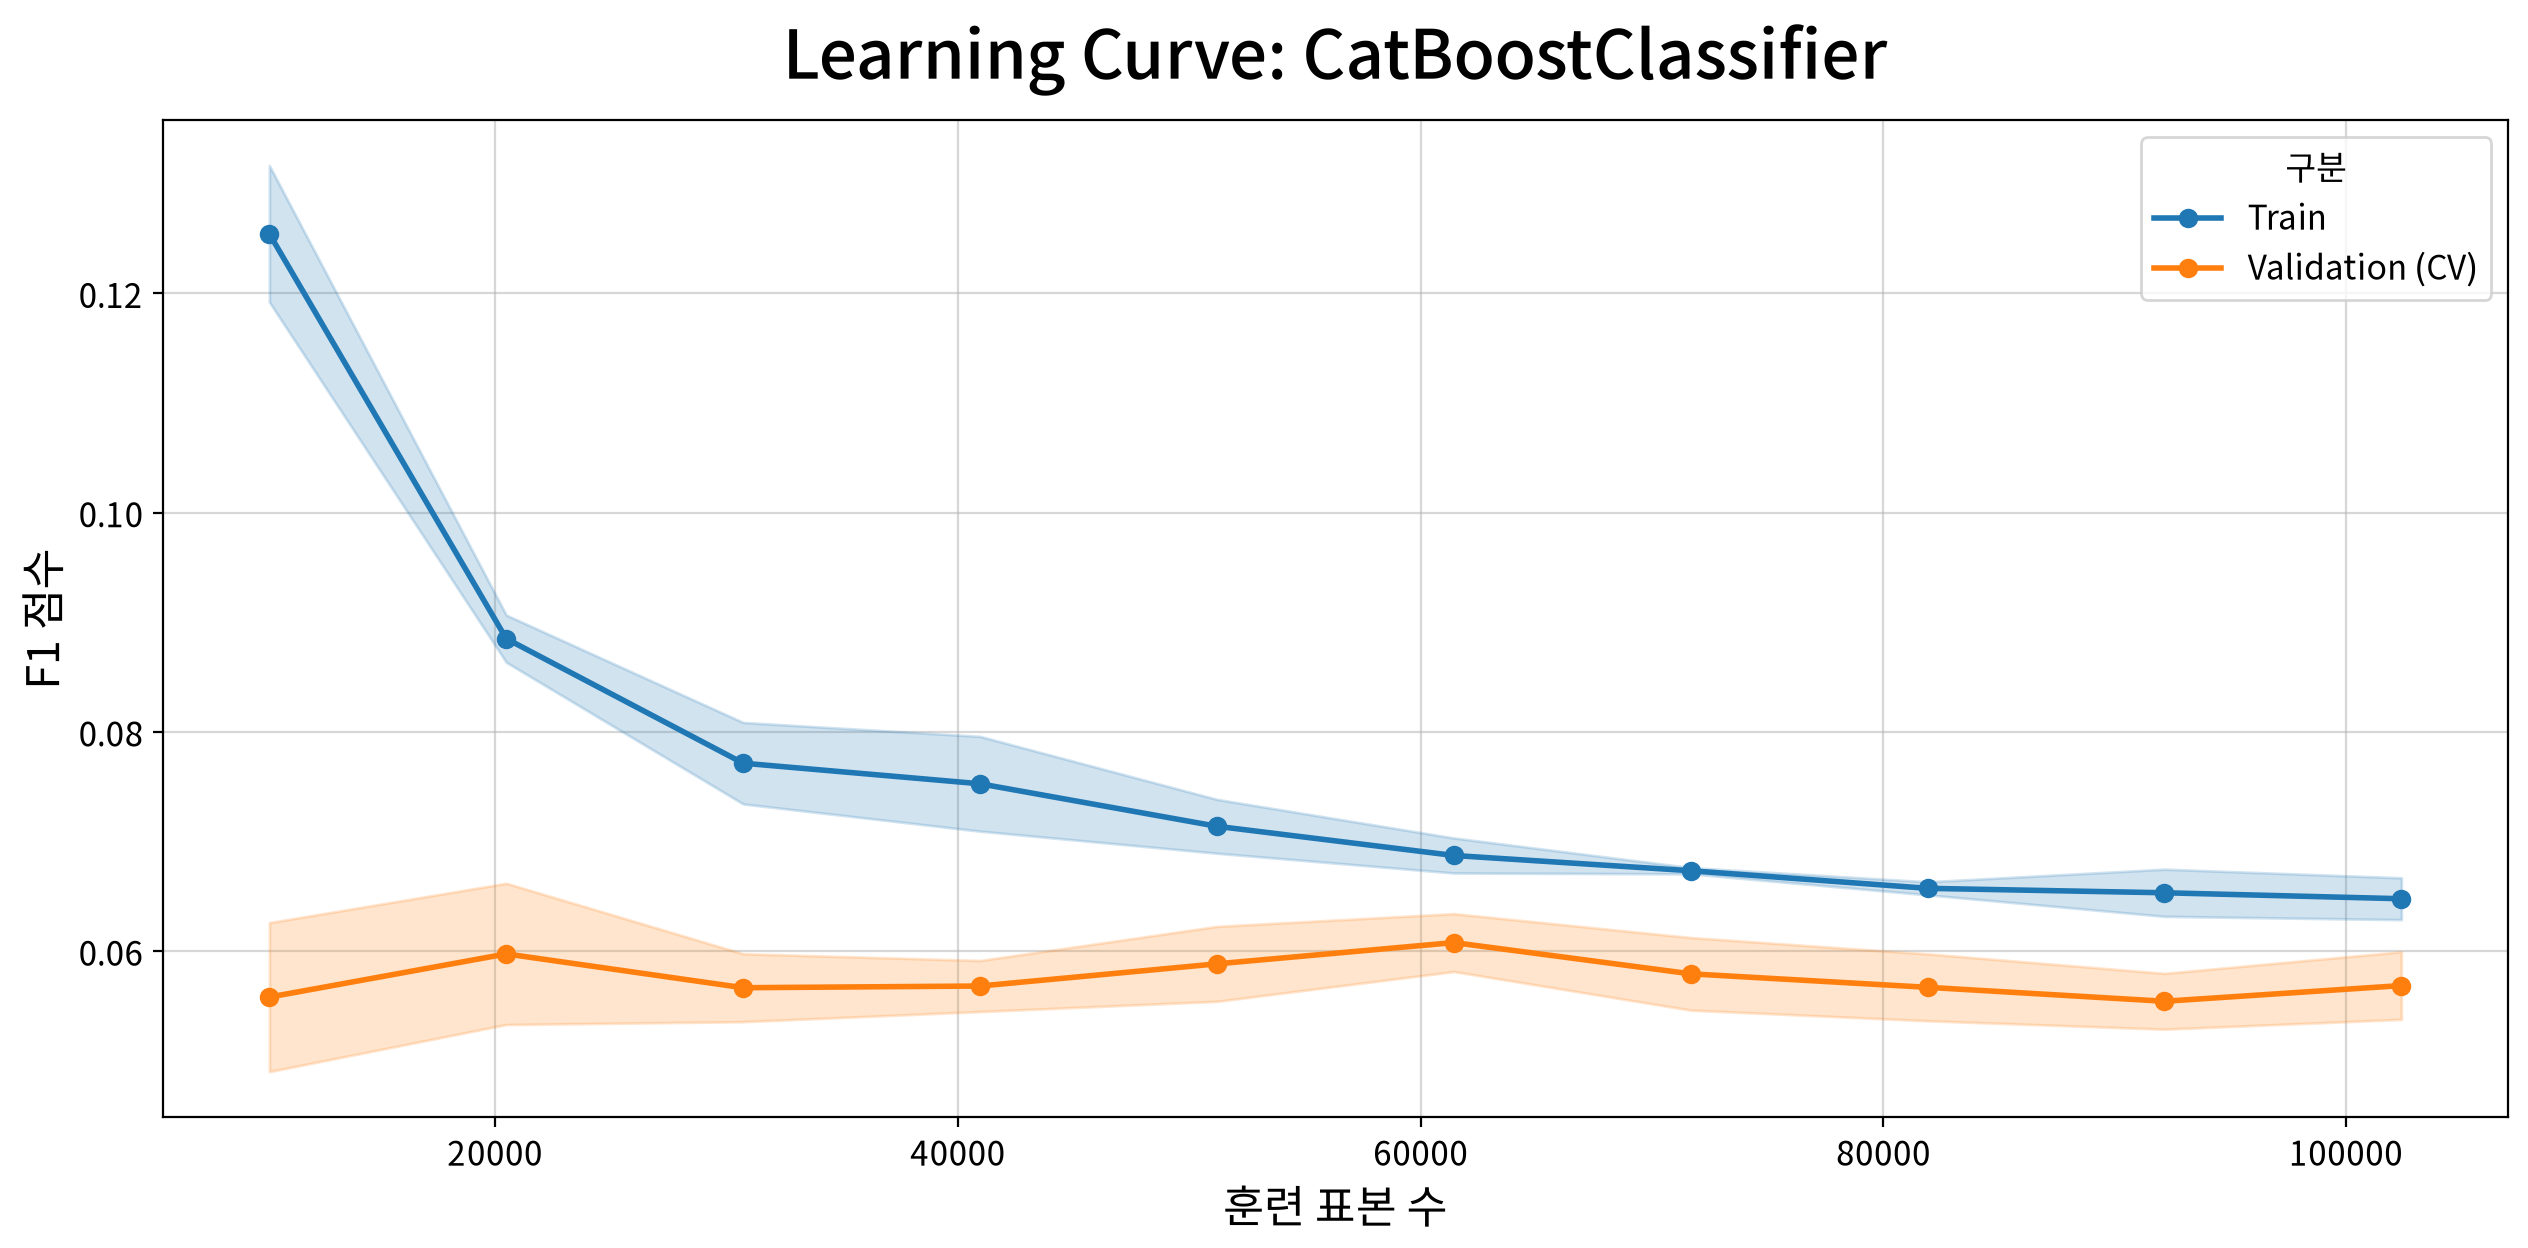

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.064396,0.056805,0.002084,0.058384,0.007590,0.76,일반화
PR_AUC,0.103057,0.037573,0.004761,0.048629,0.065485,6.55,일반화
ROC_AUC,0.852038,0.828100,0.007870,0.855255,0.023938,2.39,일반화
Recall,0.517007,0.455782,0.014270,0.445652,0.061224,6.12,일반화
Precision,0.034336,0.030291,0.001126,0.031238,0.004046,0.40,일반화
Accuracy,0.913736,0.913064,0.001286,0.917346,0.000672,0.07,일반화



◆ Fit Diagnosis: CatBoostClassifier  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.0644 CV=     0.0568 (±0.0021) Test=     0.0584 Gap=   0.0076 Gap%=   0.76% [일반화] [정상]
 - PR_AUC    Train=     0.1031 CV=     0.0376 (±0.0048) Test=     0.0486 Gap=   0.0655 Gap%=   6.55% [일반화] [정상]
 - ROC_AUC   Train=     0.8520 CV=     0.8281 (±0.0079) Test=     0.8553 Gap=   0.0239 Gap%=   2.39% [일반화] [정상]
 - Recall    Train=     0.5170 CV=     0.4558 (±0.0143) Test=     0.4457 Gap=   0.0612 Gap%=   6.12% [일반화] [정상]
 - Precision Train=     0.0343 CV=     0.0303 (±0.0011) Test=     0.0312 Gap=   0.0040 Gap%=   0.40% [일반화] [정상]
 - Accuracy  Train=     0.9137 CV=     0.9131 (±0.0013) Test=     0.9173 Gap=   0.0007 Gap%=   0.07% [일반화] [정상]

  ▶ 진단: ✔ 일반화 진단 (Good fit) - 설정한 gap 기준 내에서 격차가 작음
     · train ROC_AUC=0.8520 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8281


OVERFIT DIAGNOSIS — FIXED TUNED: l

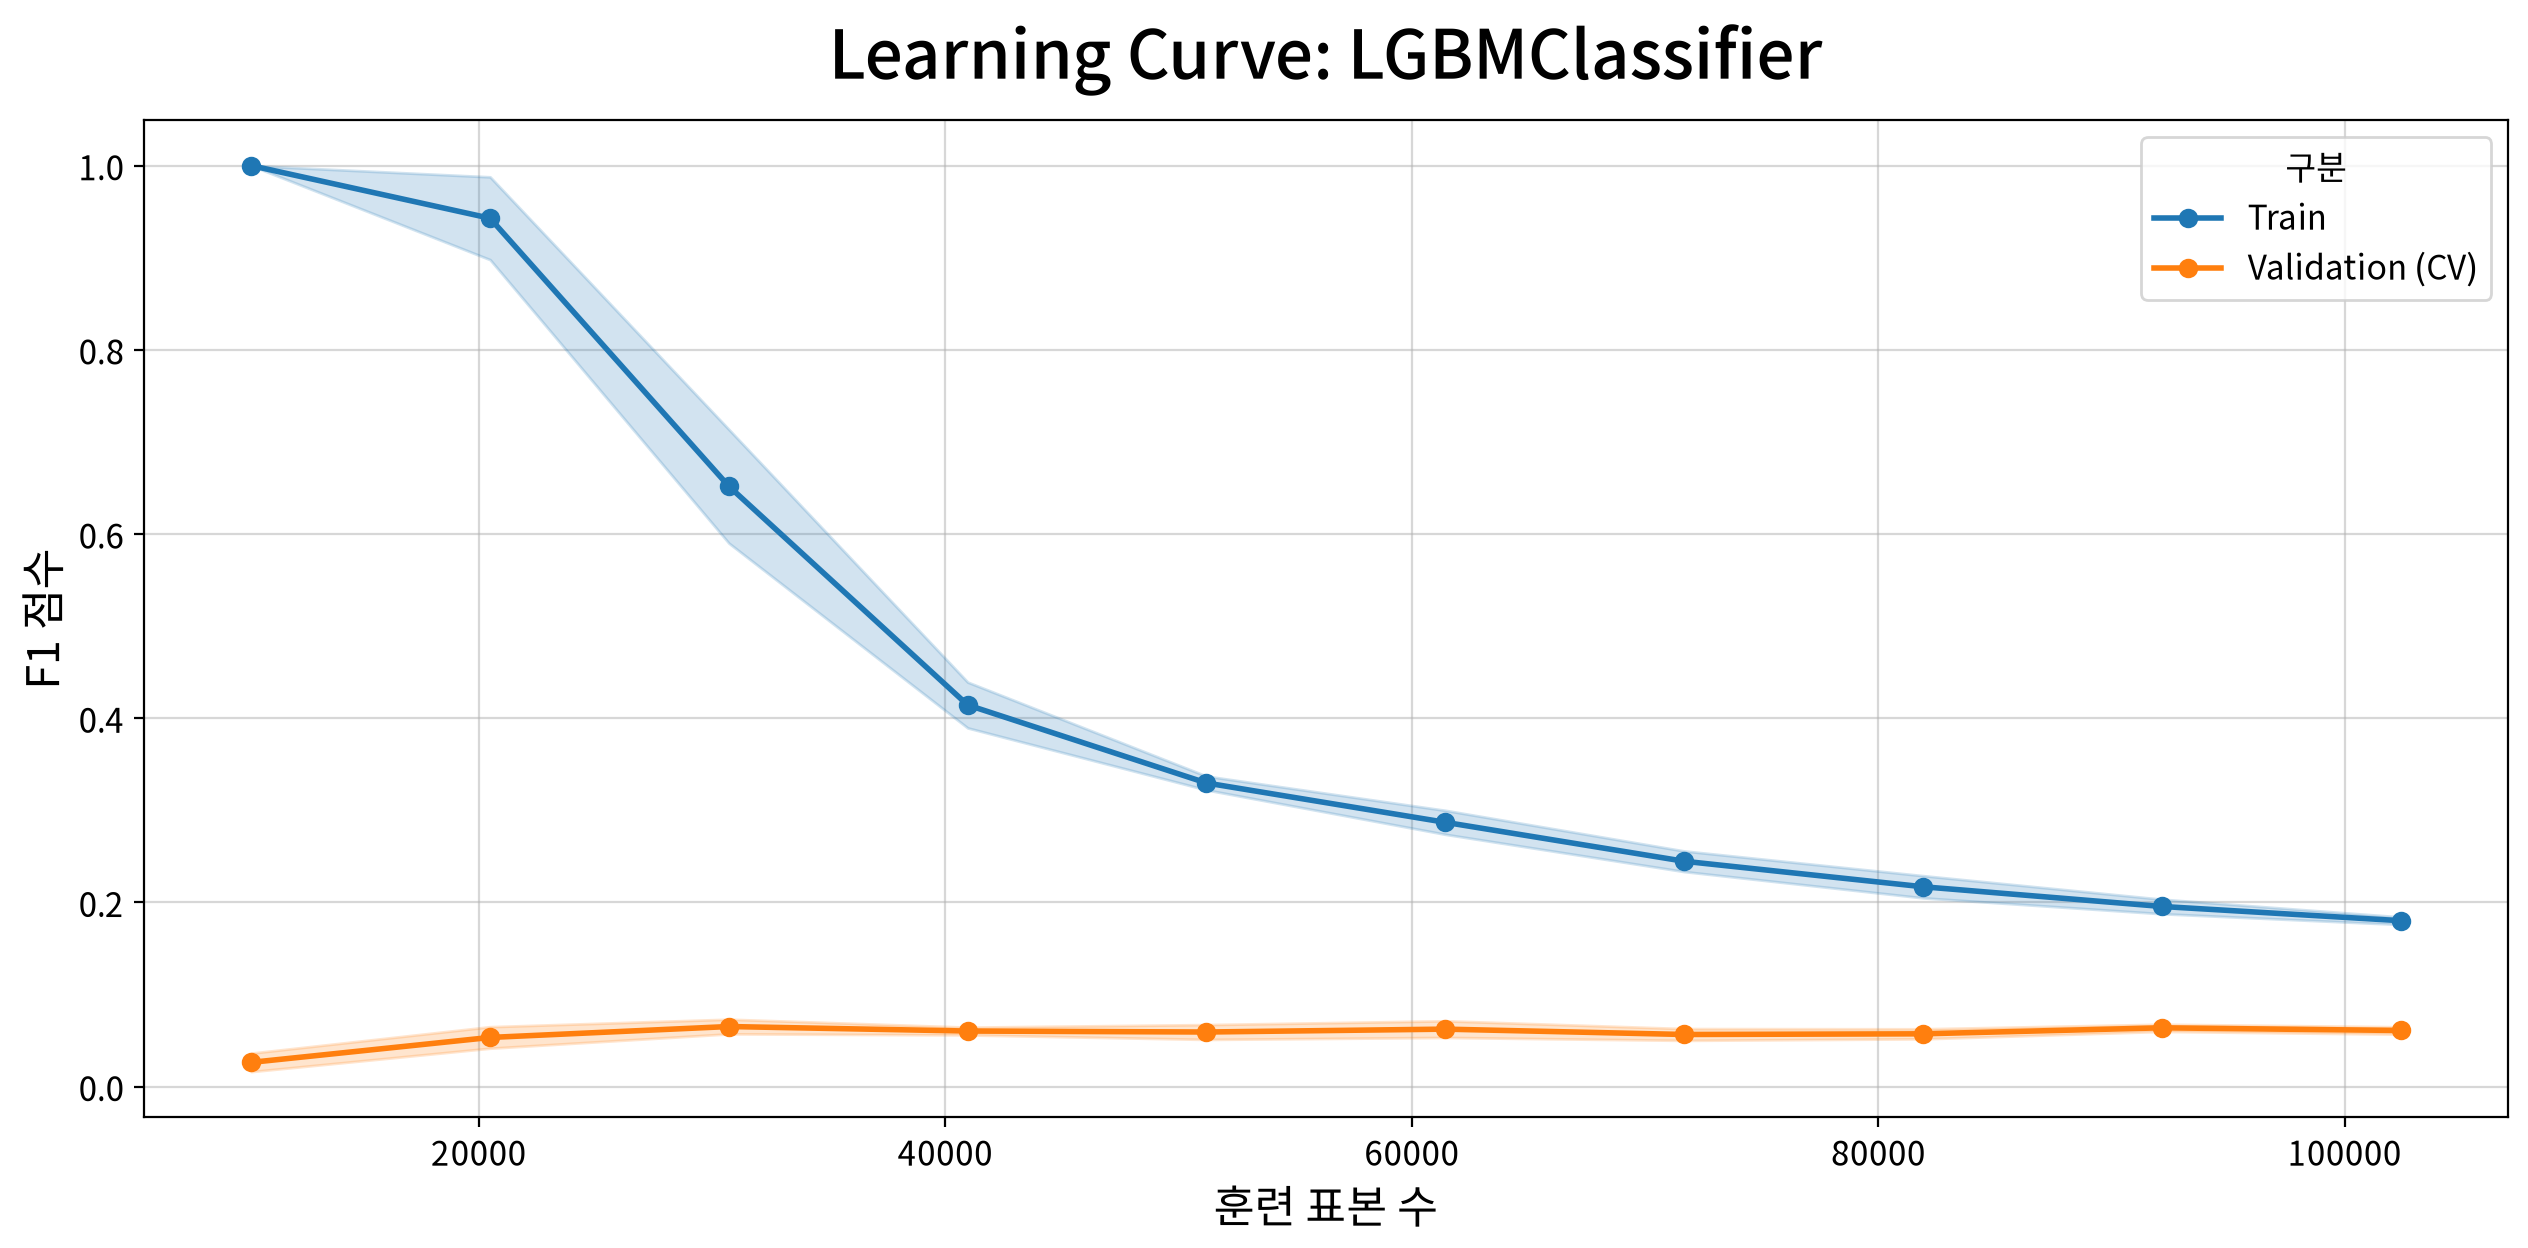

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.161546,0.059643,0.003058,0.058073,0.101903,10.19,일반화
PR_AUC,0.885596,0.029783,0.005400,0.029237,0.855813,85.58,과대적합
ROC_AUC,0.996449,0.802169,0.014635,0.829615,0.194280,19.43,일반화
Recall,0.983673,0.344218,0.027750,0.358696,0.639456,63.95,과대적합
Precision,0.087999,0.032654,0.001597,0.031594,0.055345,5.53,일반화
Accuracy,0.941368,0.937759,0.001914,0.933096,0.003609,0.36,일반화



◆ Fit Diagnosis: LGBMClassifier  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.1615 CV=     0.0596 (±0.0031) Test=     0.0581 Gap=   0.1019 Gap%=  10.19% [일반화] [정상]
 - PR_AUC    Train=     0.8856 CV=     0.0298 (±0.0054) Test=     0.0292 Gap=   0.8558 Gap%=  85.58% [과대적합] [주의]
 - ROC_AUC   Train=     0.9964 CV=     0.8022 (±0.0146) Test=     0.8296 Gap=   0.1943 Gap%=  19.43% [일반화] [정상]
 - Recall    Train=     0.9837 CV=     0.3442 (±0.0277) Test=     0.3587 Gap=   0.6395 Gap%=  63.95% [과대적합] [주의]
 - Precision Train=     0.0880 CV=     0.0327 (±0.0016) Test=     0.0316 Gap=   0.0553 Gap%=   5.53% [일반화] [정상]
 - Accuracy  Train=     0.9414 CV=     0.9378 (±0.0019) Test=     0.9331 Gap=   0.0036 Gap%=   0.36% [일반화] [정상]

  ▶ 진단: ▲ 과대적합 경고 (Overfit · 高분산) - 훈련↔CV 격차가 큼
     · train ROC_AUC=0.9964 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8022


✓ my_diag.overfit completed for Logistic

In [14]:
overfit_results = {}

for name in ["logistic", "catboost", "lgbm"]:
    estimator = fixed_tuned_models[name]

    print("\n" + "=" * 100)
    print("OVERFIT DIAGNOSIS — FIXED TUNED:", name)
    print("=" * 100)

    common_kwargs = dict(
        estimator=estimator,
        x_train=X_train_final,
        y_train=y_train,
        x_test=X_test_final,
        y_test=y_test,
        metrics=["F1","PR_AUC","ROC_AUC","Recall","Precision","Accuracy"],
        decision_threshold=THRESHOLD,
        gap_threshold=GAP_THRESHOLD,
    )

    if name == "catboost":
        result = my_diag.overfit(
            **common_kwargs,
            fit_params={"model__cat_features": list(FINAL_CATEGORICAL)},
        )
    else:
        result = my_diag.overfit(**common_kwargs)

    overfit_results[name] = result

print("\n✓ my_diag.overfit completed for Logistic + CatBoost + LightGBM.")

In [ ]:
# Final experiment audit.
print("=" * 100)
print("FINAL CONTROLLED-EXPERIMENT AUDIT")
print("=" * 100)

print("Feature count      :", len(M8_FINAL))
print("Features           :", M8_FINAL)
print("Ablated from 12F   :", ABLATION_REMOVE)
print("Categorical dtype  :", {c: str(X_train_final[c].dtype) for c in FINAL_CATEGORICAL})
print("Random state       :", RANDOM_STATE)
print("Threshold          :", THRESHOLD)
print("Train rows         :", len(X_train_final))
print("Test rows          :", len(X_test_final))

assert len(M8_FINAL) == 11
assert ABLATION_REMOVE == ["Original_UPB"]
assert "DTI_Missing" in M8_FINAL and "Original_UPB" not in M8_FINAL
assert M8_FINAL == EXPECTED_11F
assert all(
    isinstance(X_train_final[c].dtype, pd.CategoricalDtype)
    or pd.api.types.is_object_dtype(X_train_final[c].dtype)
    for c in FINAL_CATEGORICAL
)

print("\n✓ NO astype(str) applied")
print("✓ NO CatBoost constructor cat_features applied")
print("✓ CatBoost categorical columns supplied only through fit-time model__cat_features")
print("✓ Controlled 11F three-model experiment complete")

FINAL CONTROLLED-EXPERIMENT AUDIT
Feature count      : 11
Features           : ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'HARP_High_Leverage', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
Ablated from 12F   : ['Original_UPB']
Categorical dtype  : {'DTI_Missing': 'category', 'HARP_High_Leverage': 'category', 'Spatial_Cluster_Region': 'category', 'Regular_MSA_Macro_Cluster_A': 'category'}
Random state       : 3217
Threshold          : 0.015
Train rows         : 128002
Test rows          : 32001

✓ NO astype(str) applied
✓ NO CatBoost constructor cat_features applied
✓ CatBoost categorical columns supplied only through fit-time model__cat_features
✓ Controlled 11F three-model experiment complete
